# LOAD PACKAGES

In [1]:
# Air Quality Risk Prediction
# Notebook 02: Preliminary Modeling

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Final study-specific threshold used in Notebook 01
FINAL_AQI_THRESHOLD = 35

print("Packages loaded successfully.")
print(f"Final AQI threshold: overall_aqi > {FINAL_AQI_THRESHOLD}")

Packages loaded successfully.
Final AQI threshold: overall_aqi > 35


# UPLOAD CLEANED MERGED DATASET

In [2]:
from google.colab import files

uploaded = files.upload()

Saving aq_daily_merged_clean.csv to aq_daily_merged_clean.csv


# LOAD CLEANED MERGED DATASET

In [3]:
# Load cleaned merged dataset from Notebook 01

merged = pd.read_csv("aq_daily_merged_clean.csv")
merged["date"] = pd.to_datetime(merged["date"])

print("Merged dataset loaded.")
print(f"Rows: {merged.shape[0]}")
print(f"Columns: {merged.shape[1]}")
print(f"Date range: {merged['date'].min().date()} to {merged['date'].max().date()}")

merged.head()

Merged dataset loaded.
Rows: 731
Columns: 41
Date range: 2024-01-01 to 2025-12-31


,date,site_id,local_site_name,county,state,site_latitude,site_longitude,station,station_name,daily_max_8hr_ozone,daily_aqi_ozone,daily_obs_count_ozone,percent_complete_ozone,ozone_poc,daily_mean_pm10,daily_aqi_pm10,daily_obs_count_pm10,percent_complete_pm10,pm10_poc,daily_mean_pm25,daily_aqi_pm25,daily_obs_count_pm25,percent_complete_pm25,pm25_poc,daily_max_1hr_no2,daily_aqi_no2,daily_obs_count_no2,percent_complete_no2,no2_poc,awnd,prcp,tmax,tmin,overall_aqi,poor_air_quality,year,month,day_of_week,is_weekend,season,dominant_pollutant
0,2024-01-01,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.033,31.0,17.0,100.0,1.0,13.0,12.0,1.0,100.0,3.0,5.400000,32.0,2.0,100.0,"1,21",11.8,10.0,22.0,92.0,1.0,4.7,0.0,26.7,18.3,32.0,0,2024,1,Monday,0,Winter,PM2.5
1,2024-01-02,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.035,32.0,17.0,100.0,1.0,20.0,19.0,1.0,100.0,3.0,4.950000,30.0,2.0,100.0,"1,21",16.1,15.0,24.0,100.0,1.0,4.6,0.0,27.8,22.2,32.0,0,2024,1,Tuesday,0,Winter,Ozone
2,2024-01-03,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.035,32.0,17.0,100.0,1.0,25.0,23.0,1.0,100.0,3.0,5.666667,37.0,3.0,100.0,"1,2,21",13.0,12.0,24.0,100.0,1.0,3.5,0.0,28.9,19.4,37.0,1,2024,1,Wednesday,0,Winter,PM2.5
3,2024-01-04,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.033,31.0,17.0,100.0,1.0,21.0,19.0,1.0,100.0,3.0,5.833333,37.0,3.0,100.0,"1,2,21",17.4,16.0,24.0,100.0,1.0,2.4,0.0,26.7,19.4,37.0,1,2024,1,Thursday,0,Winter,PM2.5
4,2024-01-05,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.031,29.0,17.0,100.0,1.0,23.0,21.0,1.0,100.0,3.0,7.100000,42.0,2.0,100.0,"1,21",17.9,16.0,24.0,100.0,1.0,2.1,0.0,27.2,19.4,42.0,1,2024,1,Friday,0,Winter,PM2.5


# CONFIRM FINAL TARGET IS CORRECT

In [4]:
# Confirm that poor_air_quality uses the final threshold

merged["poor_air_quality_check"] = (merged["overall_aqi"] > FINAL_AQI_THRESHOLD).astype(int)

mismatch_count = (merged["poor_air_quality"] != merged["poor_air_quality_check"]).sum()

print(f"Target mismatch count: {mismatch_count}")

print("\nTarget distribution from file:")
print(merged["poor_air_quality"].value_counts().sort_index())

print("\nTarget distribution from threshold check:")
print(merged["poor_air_quality_check"].value_counts().sort_index())

# Drop check column after validation
merged = merged.drop(columns=["poor_air_quality_check"])

Target mismatch count: 0

Target distribution from file:
poor_air_quality
0    581
1    150
Name: count, dtype: int64

Target distribution from threshold check:
poor_air_quality_check
0    581
1    150
Name: count, dtype: int64


# DEFINE MODELING FEATURES AND TARGET

In [5]:
# Define modeling features and target

target_col = "poor_air_quality"

feature_cols = [
    "daily_max_8hr_ozone",
    "daily_mean_pm10",
    "daily_mean_pm25",
    "daily_max_1hr_no2",
    "tmax",
    "tmin",
    "prcp",
    "awnd",
    "month",
    "is_weekend"
]

model_df = merged[["date", target_col] + feature_cols].copy()

print("Initial modeling dataset shape:")
print(model_df.shape)

print("\nFeature columns:")
print(feature_cols)

print("\nMissing values before imputation:")
print(model_df.isna().sum().sort_values(ascending=False))

Initial modeling dataset shape:
(731, 12)

Feature columns:
['daily_max_8hr_ozone', 'daily_mean_pm10', 'daily_mean_pm25', 'daily_max_1hr_no2', 'tmax', 'tmin', 'prcp', 'awnd', 'month', 'is_weekend']

Missing values before imputation:
daily_max_1hr_no2      49
daily_mean_pm10        45
daily_mean_pm25        32
daily_max_8hr_ozone     5
prcp                    2
awnd                    2
tmax                    2
tmin                    2
date                    0
poor_air_quality        0
month                   0
is_weekend              0
dtype: int64


# MEDIAN IMPUTATION FOR MODELING FEATURES

In [6]:
# Median imputation for missing numeric predictor values

model_df_imputed = model_df.copy()

imputer = SimpleImputer(strategy="median")

model_df_imputed[feature_cols] = imputer.fit_transform(model_df_imputed[feature_cols])

print("Missing values after imputation:")
print(model_df_imputed.isna().sum().sort_values(ascending=False))

print("\nFinal modeling dataset shape:")
print(model_df_imputed.shape)

print("\nTarget distribution:")
print(model_df_imputed[target_col].value_counts().sort_index())

print("\nTarget distribution (%):")
print((model_df_imputed[target_col].value_counts(normalize=True).sort_index() * 100).round(2))

Missing values after imputation:
date                   0
poor_air_quality       0
daily_max_8hr_ozone    0
daily_mean_pm10        0
daily_mean_pm25        0
daily_max_1hr_no2      0
tmax                   0
tmin                   0
prcp                   0
awnd                   0
month                  0
is_weekend             0
dtype: int64

Final modeling dataset shape:
(731, 12)

Target distribution:
poor_air_quality
0    581
1    150
Name: count, dtype: int64

Target distribution (%):
poor_air_quality
0    79.48
1    20.52
Name: proportion, dtype: float64


# SAVE PRELIMINARY MODELING DATASET

In [7]:
# Save preliminary modeling dataset

modeling_output_file = "aq_modeling_dataset_preliminary.csv"

model_df_imputed.to_csv(modeling_output_file, index=False)

print(f"Saved: {modeling_output_file}")

Saved: aq_modeling_dataset_preliminary.csv


# DOWNLOAD MODELING DATASET

In [8]:
from google.colab import files

files.download(modeling_output_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# CREATE FEATURE MATRIX AND TARGET VECTOR

In [9]:
# Create X and y for modeling

X = model_df_imputed[feature_cols]
y = model_df_imputed[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts().sort_index())

print("\nTarget distribution (%):")
print((y.value_counts(normalize=True).sort_index() * 100).round(2))

Feature matrix shape: (731, 10)
Target shape: (731,)

Target distribution:
poor_air_quality
0    581
1    150
Name: count, dtype: int64

Target distribution (%):
poor_air_quality
0    79.48
1    20.52
Name: proportion, dtype: float64


# TRAIN/TEST SPLIT

In [10]:
# Create stratified train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

print("\nTraining target distribution (%):")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTest target distribution (%):")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Training set: (584, 10)
Test set: (147, 10)

Training target distribution:
poor_air_quality
0    464
1    120
Name: count, dtype: int64

Test target distribution:
poor_air_quality
0    117
1     30
Name: count, dtype: int64

Training target distribution (%):
poor_air_quality
0    79.45
1    20.55
Name: proportion, dtype: float64

Test target distribution (%):
poor_air_quality
0    79.59
1    20.41
Name: proportion, dtype: float64


# CELL 11: IMPORT MODELING TOOLS

In [11]:
# Import modeling tools

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

print("Modeling tools imported successfully.")

Modeling tools imported successfully.


# CELL 12: DEFINE PRELIMINARY CANDIDATE MODELS

In [12]:
# Define preliminary candidate models

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=8,
        random_state=42
    ),

    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            class_weight="balanced",
            probability=True,
            kernel="rbf",
            random_state=42
        ))
    ])
}

print("Preliminary models defined successfully.")

Preliminary models defined successfully.


# CELL 13: TRAIN AND EVALUATE PRELIMINARY MODELS

In [13]:
# Train and evaluate preliminary models

results = []
trained_models = {}

for model_name, model in models.items():
    print(f"Training: {model_name}")

    model.fit(X_train, y_train)
    trained_models[model_name] = model

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score)
    })

results_df = pd.DataFrame(results).sort_values("f1_score", ascending=False)

results_df.round(3)

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: Support Vector Machine


,model,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,0.986,0.967,0.967,0.967,0.994
1,Decision Tree,0.973,0.906,0.967,0.935,0.992
3,Support Vector Machine,0.918,0.737,0.933,0.824,0.976
0,Logistic Regression,0.878,0.658,0.833,0.735,0.934


# CELL 14: SAVE PRELIMINARY MODEL PERFORMANCE TABLE

In [14]:
# Save preliminary model performance table

results_output_file = "preliminary_model_performance.csv"

results_df.to_csv(results_output_file, index=False)

print(f"Saved: {results_output_file}")
results_df.round(3)

Saved: preliminary_model_performance.csv


,model,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,0.986,0.967,0.967,0.967,0.994
1,Decision Tree,0.973,0.906,0.967,0.935,0.992
3,Support Vector Machine,0.918,0.737,0.933,0.824,0.976
0,Logistic Regression,0.878,0.658,0.833,0.735,0.934


# CELL 15: CLASSIFICATION REPORTS

In [15]:
# Print classification reports for each model

for model_name, model in trained_models.items():
    print("\n" + "="*80)
    print(model_name)
    print("="*80)

    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.89      0.92       117
           1       0.66      0.83      0.74        30

    accuracy                           0.88       147
   macro avg       0.81      0.86      0.83       147
weighted avg       0.89      0.88      0.88       147


Decision Tree
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       117
           1       0.91      0.97      0.94        30

    accuracy                           0.97       147
   macro avg       0.95      0.97      0.96       147
weighted avg       0.97      0.97      0.97       147


Random Forest
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       117
           1       0.97      0.97      0.97        30

    accuracy                           0.99       147
   macro avg       0.98      0.98      0.98       147
weighted avg       0.99

# CELL 16: CONFUSION MATRICES

In [16]:
# Print confusion matrices for each model

for model_name, model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "="*80)
    print(model_name)
    print("="*80)
    print(cm)


Logistic Regression
[[104  13]
 [  5  25]]

Decision Tree
[[114   3]
 [  1  29]]

Random Forest
[[116   1]
 [  1  29]]

Support Vector Machine
[[107  10]
 [  2  28]]


# CELL 17: SAVE MODEL COMPARISON FIGURE

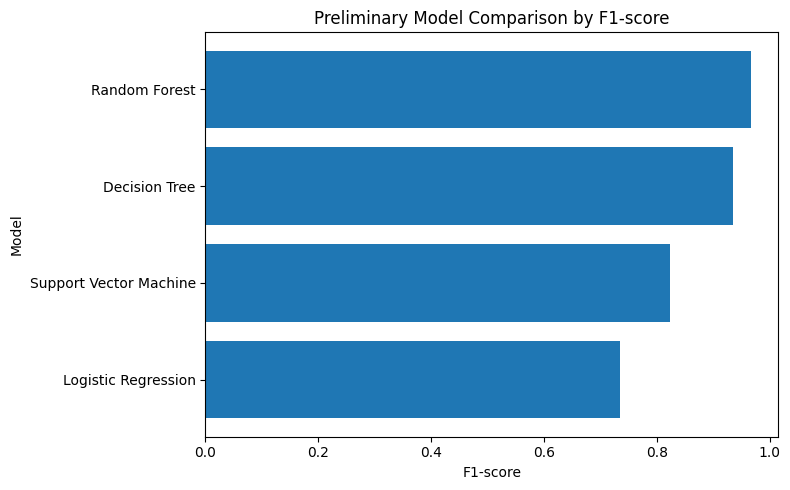

Saved: figure_06_preliminary_model_f1_comparison.png


In [17]:
# Save preliminary model comparison chart by F1-score

figures_dir = Path("outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plot_df = results_df.sort_values("f1_score", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model"], plot_df["f1_score"])
plt.title("Preliminary Model Comparison by F1-score")
plt.xlabel("F1-score")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig(figures_dir / "figure_06_preliminary_model_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_06_preliminary_model_f1_comparison.png")

# CELL 18: CROSS-VALIDATION IMPORTS

In [18]:
# Cross-validation imports

from sklearn.model_selection import StratifiedKFold, cross_validate

print("Cross-validation tools imported successfully.")

Cross-validation tools imported successfully.


# CELL 19: STRATIFIED 5-FOLD CROSS-VALIDATION

In [19]:
# Stratified 5-fold cross-validation for candidate models

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for model_name, model in models.items():
    print(f"Running cross-validation: {model_name}")

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    cv_results.append({
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "precision_mean": scores["test_precision"].mean(),
        "precision_std": scores["test_precision"].std(),
        "recall_mean": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std(),
        "f1_mean": scores["test_f1"].mean(),
        "f1_std": scores["test_f1"].std(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "roc_auc_std": scores["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("f1_mean", ascending=False)

cv_results_df.round(3)

Running cross-validation: Logistic Regression
Running cross-validation: Decision Tree
Running cross-validation: Random Forest
Running cross-validation: Support Vector Machine


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,Random Forest,0.978,0.005,0.973,0.025,0.920,0.016,0.945,0.012,0.991,0.006
1,Decision Tree,0.967,0.015,0.916,0.042,0.927,0.039,0.921,0.035,0.967,0.020
3,Support Vector Machine,0.899,0.019,0.698,0.049,0.907,0.044,0.787,0.032,0.971,0.011
0,Logistic Regression,0.858,0.026,0.611,0.055,0.880,0.069,0.719,0.040,0.941,0.017


# CELL 20: SAVE CROSS-VALIDATION RESULTS

In [20]:
# Save cross-validation results

cv_results_output_file = "cross_validation_model_performance.csv"

cv_results_df.to_csv(cv_results_output_file, index=False)

print(f"Saved: {cv_results_output_file}")
cv_results_df.round(3)

Saved: cross_validation_model_performance.csv


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
2,Random Forest,0.978,0.005,0.973,0.025,0.920,0.016,0.945,0.012,0.991,0.006
1,Decision Tree,0.967,0.015,0.916,0.042,0.927,0.039,0.921,0.035,0.967,0.020
3,Support Vector Machine,0.899,0.019,0.698,0.049,0.907,0.044,0.787,0.032,0.971,0.011
0,Logistic Regression,0.858,0.026,0.611,0.055,0.880,0.069,0.719,0.040,0.941,0.017


# CELL 21: SAVE CROSS-VALIDATION FIGURE

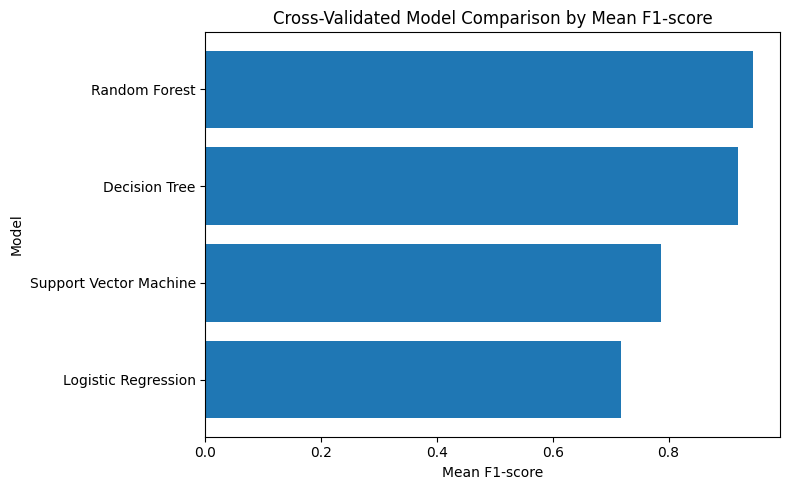

Saved: figure_07_cross_validated_model_f1_comparison.png


In [21]:
# Save cross-validation model comparison chart by mean F1-score

figures_dir = Path("outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plot_df = cv_results_df.sort_values("f1_mean", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model"], plot_df["f1_mean"])
plt.title("Cross-Validated Model Comparison by Mean F1-score")
plt.xlabel("Mean F1-score")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig(figures_dir / "figure_07_cross_validated_model_f1_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_07_cross_validated_model_f1_comparison.png")

# CELL 22: RANDOM FOREST FEATURE IMPORTANCE

In [22]:
# Random Forest feature importance

rf_model = trained_models["Random Forest"]

feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.round(4)

,feature,importance
0,daily_max_8hr_ozone,0.3270
2,daily_mean_pm25,0.2693
1,daily_mean_pm10,0.1092
4,tmax,0.0912
8,month,0.0781
5,tmin,0.0440
3,daily_max_1hr_no2,0.0372
7,awnd,0.0292
6,prcp,0.0122
9,is_weekend,0.0026


# CELL 23: SAVE RANDOM FOREST FEATURE IMPORTANCE TABLE

In [23]:
# Save Random Forest feature importance table

feature_importance_output_file = "random_forest_feature_importance.csv"

feature_importance.to_csv(feature_importance_output_file, index=False)

print(f"Saved: {feature_importance_output_file}")
feature_importance.round(4)

Saved: random_forest_feature_importance.csv


,feature,importance
0,daily_max_8hr_ozone,0.3270
2,daily_mean_pm25,0.2693
1,daily_mean_pm10,0.1092
4,tmax,0.0912
8,month,0.0781
5,tmin,0.0440
3,daily_max_1hr_no2,0.0372
7,awnd,0.0292
6,prcp,0.0122
9,is_weekend,0.0026


# CELL 24: SAVE RANDOM FOREST FEATURE IMPORTANCE FIGURE

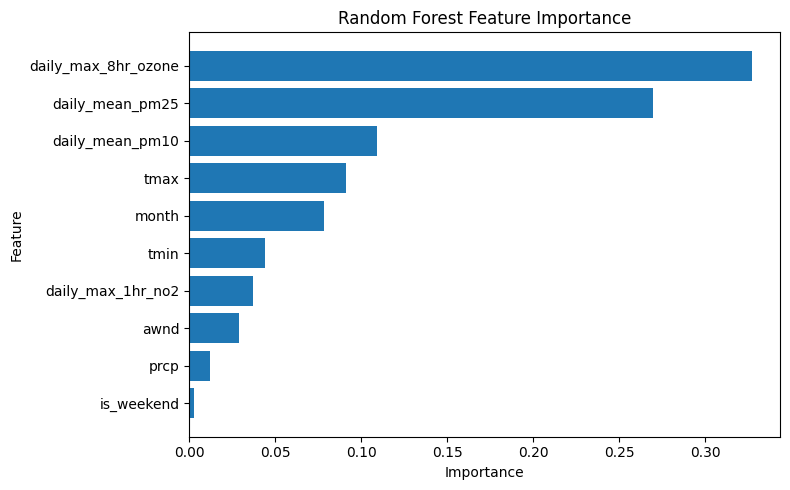

Saved: figure_08_random_forest_feature_importance.png


In [24]:
# Save Random Forest feature importance figure

plot_importance = feature_importance.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_importance["feature"], plot_importance["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(figures_dir / "figure_08_random_forest_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_08_random_forest_feature_importance.png")

# CELL 25: RANDOM FOREST CONFUSION MATRIX FIGURE

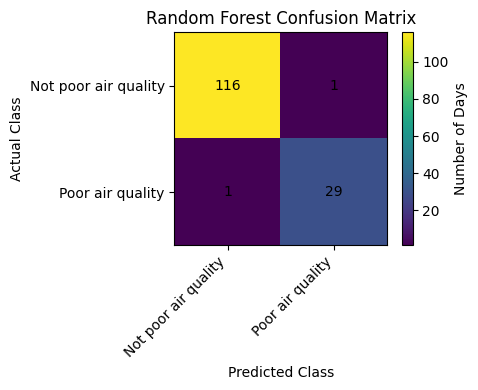

Saved: figure_09_random_forest_confusion_matrix.png
[[116   1]
 [  1  29]]


In [25]:
# Save Random Forest confusion matrix figure

best_model_name = "Random Forest"
best_model = trained_models[best_model_name]

y_pred_rf = best_model.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
plt.imshow(cm_rf)
plt.title("Random Forest Confusion Matrix")
plt.colorbar(label="Number of Days")

class_labels = ["Not poor air quality", "Poor air quality"]

plt.xticks([0, 1], class_labels, rotation=45, ha="right")
plt.yticks([0, 1], class_labels)

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        plt.text(j, i, cm_rf[i, j], ha="center", va="center")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.savefig(figures_dir / "figure_09_random_forest_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figure_09_random_forest_confusion_matrix.png")
print(cm_rf)

# CELL 26: DOWNLOAD MODELING OUTPUT FILES

In [26]:
# Zip modeling outputs for download

import shutil
from google.colab import files

# Create folders if needed
Path("outputs/tables").mkdir(parents=True, exist_ok=True)

# Move/copy key tables into outputs/tables
for file_name in [
    "preliminary_model_performance.csv",
    "cross_validation_model_performance.csv",
    "random_forest_feature_importance.csv"
]:
    source = Path(file_name)
    destination = Path("outputs/tables") / file_name

    if source.exists():
        destination.write_bytes(source.read_bytes())
        print(f"Copied: {file_name} -> outputs/tables/{file_name}")

# Zip outputs folder
shutil.make_archive("modeling_outputs", "zip", "outputs")

files.download("modeling_outputs.zip")

print("Created and downloaded: modeling_outputs.zip")

Copied: preliminary_model_performance.csv -> outputs/tables/preliminary_model_performance.csv
Copied: cross_validation_model_performance.csv -> outputs/tables/cross_validation_model_performance.csv
Copied: random_forest_feature_importance.csv -> outputs/tables/random_forest_feature_importance.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Created and downloaded: modeling_outputs.zip
